## 1. 必要なライブラリのインポート

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

## 2. IRCデータの読み込み

In [6]:
def parse_irc_trajectory(filepath):
    """IRCトラジェクトリファイルからエネルギーと座標を抽出"""
    energies = []
    structures = []

    with open(filepath, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        # 最初の行は原子数
        if i < len(lines) and lines[i].strip().isdigit():
            natoms = int(lines[i].strip())

            # 次の行でエネルギーを抽出
            if i + 1 < len(lines):
                header = lines[i + 1]
                # "E -399.090227676608" からエネルギーを抽出
                match = re.search(r"E\s+([-\d.]+)", header)
                if match:
                    energy = float(match.group(1))
                    energies.append(energy)

                    # 原子座標を読み込む
                    coords = []
                    for j in range(natoms):
                        if i + 2 + j < len(lines):
                            parts = lines[i + 2 + j].split()
                            if len(parts) >= 4:
                                coords.append(
                                    [float(parts[1]), float(parts[2]), float(parts[3])]
                                )
                    structures.append(coords)

            i += natoms + 2
        else:
            i += 1

    return np.array(energies), structures


def calculate_cn_distance(structures, c_index=12, n_index=1):
    """構造からC-N距離を計算（C_idx=11, N_idx=0）"""
    distances = []
    for coords in structures:
        if len(coords) > max(c_index, n_index):
            c_pos = np.array(coords[c_index])
            n_pos = np.array(coords[n_index])
            dist = np.linalg.norm(c_pos - n_pos)
            distances.append(dist)
    return np.array(distances)


# IRCトラジェクトリファイルを読み込む
irc_file = "irc_IRC_Full_trj.xyz"
energies, structures = parse_irc_trajectory(irc_file)
cn_distances = calculate_cn_distance(structures)

print(f"読み込まれた構造数: {len(energies)}")
print(f"エネルギー範囲: {energies.min():.6f} - {energies.max():.6f}")
print(f"C-N距離範囲: {cn_distances.min():.6f} - {cn_distances.max():.6f}")

読み込まれた構造数: 75
エネルギー範囲: -399.091837 - -399.088476
C-N距離範囲: 1.664843 - 2.509560


## 3. エネルギー曲線のプロット

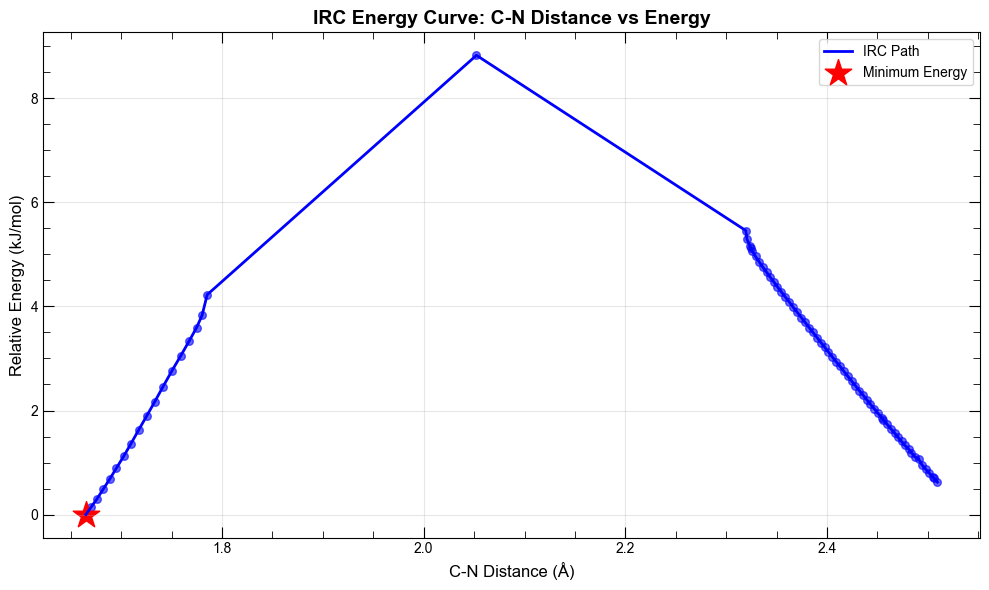


最小エネルギー点:
  C-N距離: 1.6648 Å
  エネルギー: -399.091837 au


In [7]:
plt.figure(figsize=(10, 6))

# エネルギーを相対エネルギー（最小値からの偏差）に変換
relative_energies = (energies - energies.min()) * 2625.5  # au to kJ/mol

plt.plot(cn_distances, relative_energies, "b-", linewidth=2, label="IRC Path")
plt.scatter(cn_distances, relative_energies, marker="o", s=30, color="blue", alpha=0.6)

# 最小エネルギー点をマーク
min_idx = np.argmin(energies)
plt.scatter(
    cn_distances[min_idx],
    relative_energies[min_idx],
    marker="*",
    s=400,
    color="red",
    label="Minimum Energy",
)

plt.xlabel("C-N Distance (Å)", fontsize=12)
plt.ylabel("Relative Energy (kJ/mol)", fontsize=12)
plt.title("IRC Energy Curve: C-N Distance vs Energy", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n最小エネルギー点:")
print(f"  C-N距離: {cn_distances[min_idx]:.4f} Å")
print(f"  エネルギー: {energies[min_idx]:.6f} au")

## 4. 詳細情報の表示

In [8]:
# 統計情報の出力
print("\n=== IRCパス統計 ===")
print(f"総構造数: {len(energies)}")
print(f"\nC-N距離:")
print(f"  最小: {cn_distances.min():.4f} Å")
print(f"  最大: {cn_distances.max():.4f} Å")
print(f"  範囲: {cn_distances.max() - cn_distances.min():.4f} Å")
print(f"\nエネルギー (au):")
print(f"  最小: {energies.min():.6f}")
print(f"  最大: {energies.max():.6f}")
print(f"  エネルギー差: {(energies.max() - energies.min()) * 2625.5:.2f} kJ/mol")
print(f"\n反応物側 (最初):")
print(f"  C-N距離: {cn_distances[0]:.4f} Å")
print(f"  相対エネルギー: {(energies[0] - energies.min()) * 2625.5:.2f} kJ/mol")
print(f"\n生成物側 (最後):")
print(f"  C-N距離: {cn_distances[-1]:.4f} Å")
print(f"  相対エネルギー: {(energies[-1] - energies.min()) * 2625.5:.2f} kJ/mol")


=== IRCパス統計 ===
総構造数: 75

C-N距離:
  最小: 1.6648 Å
  最大: 2.5096 Å
  範囲: 0.8447 Å

エネルギー (au):
  最小: -399.091837
  最大: -399.088476
  エネルギー差: 8.82 kJ/mol

反応物側 (最初):
  C-N距離: 2.5096 Å
  相対エネルギー: 0.62 kJ/mol

生成物側 (最後):
  C-N距離: 1.6648 Å
  相対エネルギー: 0.00 kJ/mol
